In [1]:
# CPU allocation: set an inclusive range, or leave both as None to retain scheduler affinity.
import os
CPU_START = None
CPU_STOP = None
_available = sorted(os.sched_getaffinity(0)) if hasattr(os, 'sched_getaffinity') else list(range(os.cpu_count() or 1))
if CPU_START is not None or CPU_STOP is not None:
    if CPU_START is None or CPU_STOP is None:
        raise ValueError('Set both CPU_START and CPU_STOP, or leave both as None.')
    _requested = [cpu for cpu in _available if int(CPU_START) <= cpu <= int(CPU_STOP)]
    if not _requested:
        raise ValueError(f'Requested CPU range [{CPU_START}, {CPU_STOP}] does not intersect {_available}.')
    os.sched_setaffinity(0, set(_requested))
_active_cpus = sorted(os.sched_getaffinity(0)) if hasattr(os, 'sched_getaffinity') else _available
for _name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
    os.environ[_name] = str(max(1, len(_active_cpus)))
os.environ['NUMEXPR_NUM_THREADS'] = str(max(1, min(64, len(_active_cpus))))
print(f'Notebook CPU affinity ({len(_active_cpus)} CPUs): {_active_cpus}')

Notebook CPU affinity (112 CPUs): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


# N16 Charge-Sharpening Comparison: `dwtrunc0` vs `dwtrunc1`

This notebook loads the completed CPU campaigns only. It does not rerun dynamics. The comparison is intentionally split into raw observables and per-measured-mode observables because `dwtrunc1` measures the domain-wall slab while `dwtrunc0` measures the full top layer.

In [2]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'colab_charge_fluctuations').exists():
    ROOT = ROOT.parent
if not (ROOT / 'colab_charge_fluctuations').exists():
    raise FileNotFoundError('Could not locate repository root containing colab_charge_fluctuations/.')

BUNDLE_ROOT = ROOT / 'colab_charge_fluctuations'
for candidate in (ROOT / 'src', BUNDLE_ROOT / 'src'):
    candidate_text = str(candidate)
    if candidate_text in sys.path:
        sys.path.remove(candidate_text)
    sys.path.insert(0, candidate_text)

from charge_sharpening_alpha_sweep_loader import load_charge_sharpening_campaign
from fgtn.classA_U1FGTN import classA_U1FGTN

CAMPAIGNS = {
    'dwtrunc1': 'N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_cycles-2Ny',
    'dwtrunc0': 'N16_alpha-sweep_nsh1_dwtrunc0_init-maxmix_S10_cycles-2Ny',
}
ANALYSIS_NAME = 'dwtrunc0_vs_dwtrunc1_N16_alpha_sweep'
analysis_root = BUNDLE_ROOT / 'analysis_outputs' / 'purification_charge_sharpening_alpha_sweep_cpu' / ANALYSIS_NAME
figure_root = analysis_root / 'figures'
table_root = analysis_root / 'tables'
figure_root.mkdir(parents=True, exist_ok=True)
table_root.mkdir(parents=True, exist_ok=True)
print(f'Analysis output: {analysis_root}')

Analysis output: /home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep


## Load And Validate Campaigns

In [3]:
TRUNC_LABELS = {'dwtrunc1': 'DW slab, truncated', 'dwtrunc0': 'full layer, untruncated'}
TRUNC_STYLES = {'dwtrunc1': '-', 'dwtrunc0': '--'}
TRUNC_MARKERS = {'dwtrunc1': 'o', 'dwtrunc0': 's'}
PROTOCOL_LABELS = {'perfect_correction': 'perfect correction', 'postselection': 'postselection'}
SHARPENING_THRESHOLD = 1e-2
DENSITY_SHARPENING_THRESHOLD = 1e-4

payloads = {}
inventories = []
trajectories = []
steadies = []
diagnostics = []
for truncation, campaign_id in CAMPAIGNS.items():
    payload = load_charge_sharpening_campaign(BUNDLE_ROOT, campaign_id=campaign_id, require_complete=True)
    payloads[truncation] = payload
    for table_name, frames in (
        ('inventory_df', inventories),
        ('trajectory_df', trajectories),
        ('steady_state_df', steadies),
        ('critical_diagnostics_df', diagnostics),
    ):
        frame = payload[table_name].copy()
        frame.insert(0, 'truncation', truncation)
        frame.insert(1, 'campaign_id', campaign_id)
        frames.append(frame)

inventory_df = pd.concat(inventories, ignore_index=True)
trajectory_df = pd.concat(trajectories, ignore_index=True)
steady_state_df = pd.concat(steadies, ignore_index=True)
critical_diagnostics_df = pd.concat(diagnostics, ignore_index=True)

assert len(inventory_df) == 108, len(inventory_df)
assert len(steady_state_df) == 108, len(steady_state_df)
assert len(trajectory_df) == 28512, len(trajectory_df)
assert inventory_df['complete'].all()
for truncation in CAMPAIGNS:
    sub = inventory_df.query('truncation == @truncation')
    assert len(sub) == 54
    assert sub.query("protocol == 'perfect_correction'")['samples_completed'].sum() == 270
    assert sub.query("protocol == 'postselection'")['samples_completed'].sum() == 27
assert set(inventory_df.query("truncation == 'dwtrunc1'")['observable_region']) == {'domain_wall_slab'}
assert set(inventory_df.query("truncation == 'dwtrunc0'")['observable_region']) == {'full_top_layer'}
assert set(inventory_df['Ny']) == {16, 24, 32}
assert all(int(row.cycles) == 2 * int(row.Ny) for row in inventory_df.itertuples())

print('Validation passed')
print('Inventory rows:', len(inventory_df))
print('Trajectory rows:', len(trajectory_df))
print('Steady-state rows:', len(steady_state_df))
display(inventory_df.groupby(['truncation', 'protocol'])['samples_completed'].sum().astype(int).to_frame())

Validation passed
Inventory rows: 108
Trajectory rows: 28512
Steady-state rows: 108


samples_completed
truncation protocol                             
dwtrunc0   perfect_correction                270
           postselection                      27
dwtrunc1   perfect_correction                270
           postselection                      27

## Derived Tables

In [4]:
def measured_modes(nx: int, ny: int, dw_truncation: bool) -> int:
    with contextlib.redirect_stdout(io.StringIO()):
        model = classA_U1FGTN(
            int(nx), int(ny), DW=True, nshell=1, alpha_1=1.0, alpha_2=30.0,
            trial_orbitals='X', dw_truncation=bool(dw_truncation)
        )
        model.construct_OW_projectors(nshell=1, DW=True, trial_orbitals='X', dw_truncation=bool(dw_truncation))
    return int(len(model.active_top_layer_indices(meas_slab_only=True)))

mode_lookup = {
    (int(nx), int(ny), bool(dw)): measured_modes(nx, ny, dw)
    for nx, ny, dw in inventory_df[['Nx', 'Ny', 'dw_truncation']].drop_duplicates().itertuples(index=False)
}
for frame in (inventory_df, trajectory_df, steady_state_df):
    frame['measured_modes'] = [
        mode_lookup[(int(nx), int(ny), bool(dw))]
        for nx, ny, dw in frame[['Nx', 'Ny', 'dw_truncation']].itertuples(index=False)
    ]
    frame['truncation_label'] = frame['truncation'].map(TRUNC_LABELS)

trajectory_df['entropy_per_mode'] = trajectory_df['total_entropy'] / trajectory_df['measured_modes']
trajectory_df['charge_variance_per_mode'] = trajectory_df['total_charge_variance'] / trajectory_df['measured_modes']
steady_state_df['entropy_per_mode_mean'] = steady_state_df['total_entropy_mean'] / steady_state_df['measured_modes']
steady_state_df['entropy_per_mode_std'] = steady_state_df['total_entropy_std'] / steady_state_df['measured_modes']
steady_state_df['charge_variance_per_mode_mean'] = steady_state_df['total_charge_variance_mean'] / steady_state_df['measured_modes']
steady_state_df['charge_variance_per_mode_std'] = steady_state_df['total_charge_variance_std'] / steady_state_df['measured_modes']

final_trajectory_df = trajectory_df.loc[
    trajectory_df['cycle'] == trajectory_df.groupby(['truncation', 'config_id'])['cycle'].transform('max')
].copy()
density_fraction = (
    final_trajectory_df.groupby(['truncation', 'protocol', 'Nx', 'Ny', 'alpha_topological_region'], as_index=False)
    .agg(density_sharpening_fraction=('charge_variance_per_mode', lambda values: float(np.mean(values < DENSITY_SHARPENING_THRESHOLD))))
)
steady_state_df = steady_state_df.merge(
    density_fraction,
    on=['truncation', 'protocol', 'Nx', 'Ny', 'alpha_topological_region'],
    how='left',
)

dynamics_df = (
    trajectory_df.groupby(['truncation', 'protocol', 'Ny', 'alpha_topological_region', 'cycle'], as_index=False)
    .agg(
        total_entropy_mean=('total_entropy', 'mean'),
        total_entropy_std=('total_entropy', lambda values: values.std(ddof=1) if len(values) > 1 else 0.0),
        total_charge_variance_mean=('total_charge_variance', 'mean'),
        total_charge_variance_std=('total_charge_variance', lambda values: values.std(ddof=1) if len(values) > 1 else 0.0),
        entropy_per_mode_mean=('entropy_per_mode', 'mean'),
        entropy_per_mode_std=('entropy_per_mode', lambda values: values.std(ddof=1) if len(values) > 1 else 0.0),
        charge_variance_per_mode_mean=('charge_variance_per_mode', 'mean'),
        charge_variance_per_mode_std=('charge_variance_per_mode', lambda values: values.std(ddof=1) if len(values) > 1 else 0.0),
    )
)

for name, frame in {
    'campaign_inventory_comparison': inventory_df,
    'trajectory_observables_comparison': trajectory_df,
    'steady_state_comparison': steady_state_df,
    'dynamics_comparison': dynamics_df,
    'critical_diagnostics_comparison': critical_diagnostics_df,
    'final_trajectory_comparison': final_trajectory_df,
}.items():
    numeric = frame.select_dtypes(include=[np.number]).to_numpy()
    assert np.all(np.isfinite(numeric)), name
    frame.to_csv(table_root / f'{name}.csv', index=False)

print('Measured modes:')
display(inventory_df[['truncation', 'Nx', 'Ny', 'observable_region', 'measured_modes']].drop_duplicates().sort_values(['truncation', 'Ny']))
display(steady_state_df.head())

Measured modes:


,truncation,Nx,Ny,observable_region,measured_modes
54,dwtrunc0,16,16,full_top_layer,512
63,dwtrunc0,16,24,full_top_layer,768
72,dwtrunc0,16,32,full_top_layer,1024
0,dwtrunc1,16,16,domain_wall_slab,352
9,dwtrunc1,16,24,domain_wall_slab,528
18,dwtrunc1,16,32,domain_wall_slab,704


,truncation,campaign_id,protocol,Nx,Ny,alpha_topological_region,dw_truncation,observable_region,samples,steady_state_cycle,...,total_charge_variance_mean,total_charge_variance_std,sharpening_fraction,measured_modes,truncation_label,entropy_per_mode_mean,entropy_per_mode_std,charge_variance_per_mode_mean,charge_variance_per_mode_std,density_sharpening_fraction
0,dwtrunc1,N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_...,perfect_correction,16,16,1.0,True,domain_wall_slab,10,32,...,5.743459e-02,6.546899e-02,0.2,352,"DW slab, truncated",6.174703e-04,5.726636e-04,1.631664e-04,1.859914e-04,0.6
1,dwtrunc1,N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_...,perfect_correction,16,16,1.5,True,domain_wall_slab,10,32,...,1.503590e-01,8.437685e-02,0.0,352,"DW slab, truncated",1.423277e-03,6.662337e-04,4.271562e-04,2.397069e-04,0.1
2,dwtrunc1,N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_...,perfect_correction,16,16,1.8,True,domain_wall_slab,10,32,...,4.521610e-02,7.970423e-02,0.5,352,"DW slab, truncated",4.480673e-04,6.397512e-04,1.284548e-04,2.264325e-04,0.8
3,dwtrunc1,N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_...,perfect_correction,16,16,1.9,True,domain_wall_slab,10,32,...,6.736909e-04,1.253555e-03,1.0,352,"DW slab, truncated",1.367203e-05,2.391722e-05,1.913895e-06,3.561236e-06,1.0
4,dwtrunc1,N16_alpha-sweep_nsh1_dwtrunc1_init-maxmix_S10_...,perfect_correction,16,16,2.0,True,domain_wall_slab,10,32,...,3.742576e-07,8.548529e-07,1.0,352,"DW slab, truncated",1.504604e-08,3.395791e-08,1.063232e-09,2.428559e-09,1.0


## Figure Style

In [5]:
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['CMU Sans Serif', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
NY_VALUES = tuple(sorted(int(value) for value in steady_state_df['Ny'].unique()))
NY_COLORS = {ny: color for ny, color in zip(NY_VALUES, ('#0072B2', '#D55E00', '#009E73'))}
OBSERVABLES = (
    ('total_entropy', 'Entropy', r'$S_{\mathrm{global}}$', 1e-8),
    ('total_charge_variance', 'Charge variance', r'$\delta Q^2$', 1e-12),
)

def save_figure(fig, name):
    fig.savefig(figure_root / f'{name}.png')
    fig.savefig(figure_root / f'{name}.pdf')
    print(figure_root / f'{name}.png')

## Final Raw Observables

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_raw_entropy_charge_variance_vs_alpha_dwtrunc_comparison.png


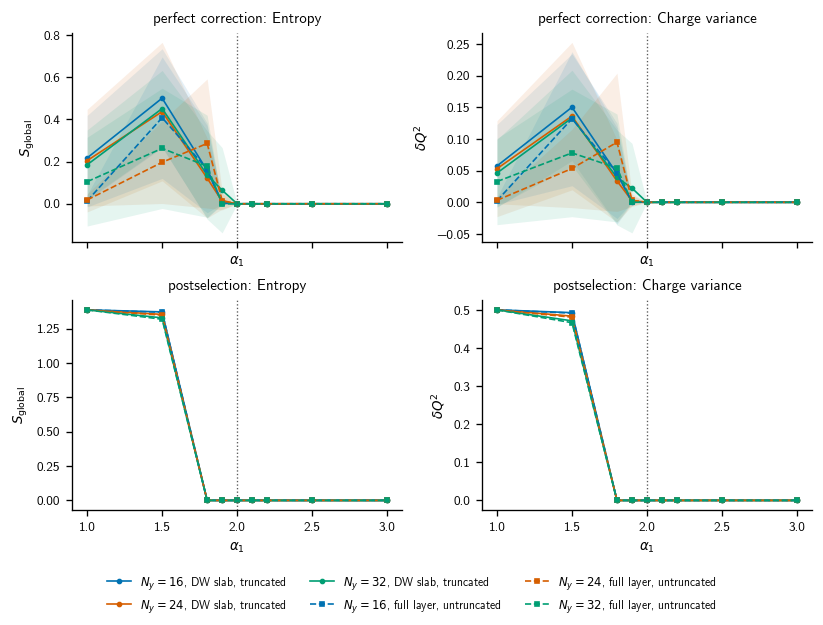

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.1), constrained_layout=True, sharex=True)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, (field, title, ylabel, _) in enumerate(OBSERVABLES):
        ax = axes[row, col]
        for truncation in ('dwtrunc1', 'dwtrunc0'):
            for ny in NY_VALUES:
                data = steady_state_df.query('protocol == @protocol and truncation == @truncation and Ny == @ny').sort_values('alpha_topological_region')
                x = data['alpha_topological_region'].to_numpy()
                y = data[f'{field}_mean'].to_numpy()
                err = data[f'{field}_std'].to_numpy()
                ax.plot(x, y, TRUNC_STYLES[truncation], marker=TRUNC_MARKERS[truncation], ms=2.4, lw=1.0, color=NY_COLORS[ny], label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}')
                if protocol == 'perfect_correction':
                    ax.fill_between(x, y - err, y + err, color=NY_COLORS[ny], alpha=0.10, linewidth=0)
        ax.axvline(2.0, color='0.35', lw=0.8, ls=':')
        ax.set_title(f'{PROTOCOL_LABELS[protocol]}: {title}')
        ax.set_xlabel(r'$\alpha_1$')
        ax.set_ylabel(ylabel)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'final_raw_entropy_charge_variance_vs_alpha_dwtrunc_comparison')
plt.show()

## Final Per-Mode Observables

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_density_entropy_charge_variance_vs_alpha_dwtrunc_comparison.png


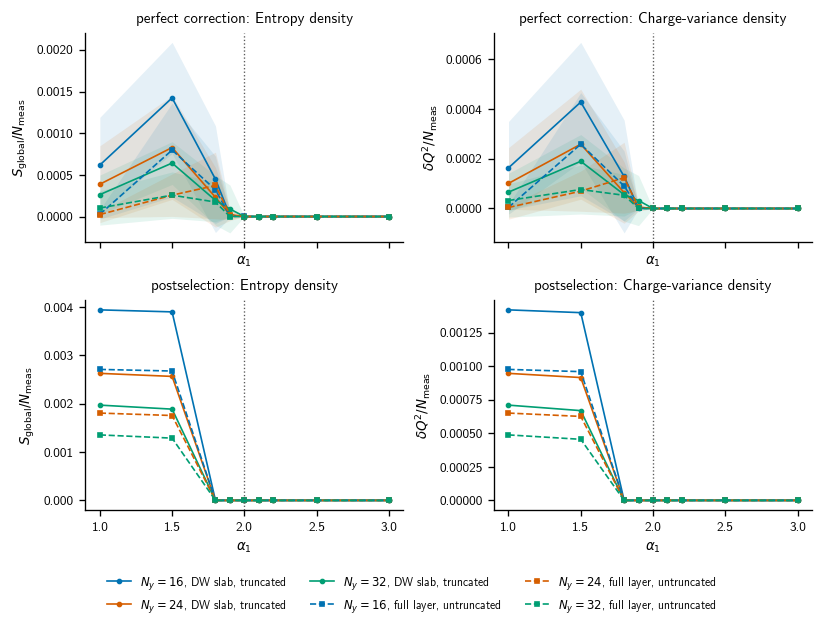

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.1), constrained_layout=True, sharex=True)
FIELDS = (
    ('entropy_per_mode', 'Entropy density', r'$S_{\mathrm{global}}/N_{\mathrm{meas}}$'),
    ('charge_variance_per_mode', 'Charge-variance density', r'$\delta Q^2/N_{\mathrm{meas}}$'),
)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, (field, title, ylabel) in enumerate(FIELDS):
        ax = axes[row, col]
        for truncation in ('dwtrunc1', 'dwtrunc0'):
            for ny in NY_VALUES:
                data = steady_state_df.query('protocol == @protocol and truncation == @truncation and Ny == @ny').sort_values('alpha_topological_region')
                x = data['alpha_topological_region'].to_numpy()
                y = data[f'{field}_mean'].to_numpy()
                err = data[f'{field}_std'].to_numpy()
                ax.plot(x, y, TRUNC_STYLES[truncation], marker=TRUNC_MARKERS[truncation], ms=2.4, lw=1.0, color=NY_COLORS[ny], label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}')
                if protocol == 'perfect_correction':
                    ax.fill_between(x, y - err, y + err, color=NY_COLORS[ny], alpha=0.10, linewidth=0)
        ax.axvline(2.0, color='0.35', lw=0.8, ls=':')
        ax.set_title(f'{PROTOCOL_LABELS[protocol]}: {title}')
        ax.set_xlabel(r'$\alpha_1$')
        ax.set_ylabel(ylabel)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'final_density_entropy_charge_variance_vs_alpha_dwtrunc_comparison')
plt.show()

## Sharpening Fractions

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_sharpening_fraction_raw_and_density_dwtrunc_comparison.png


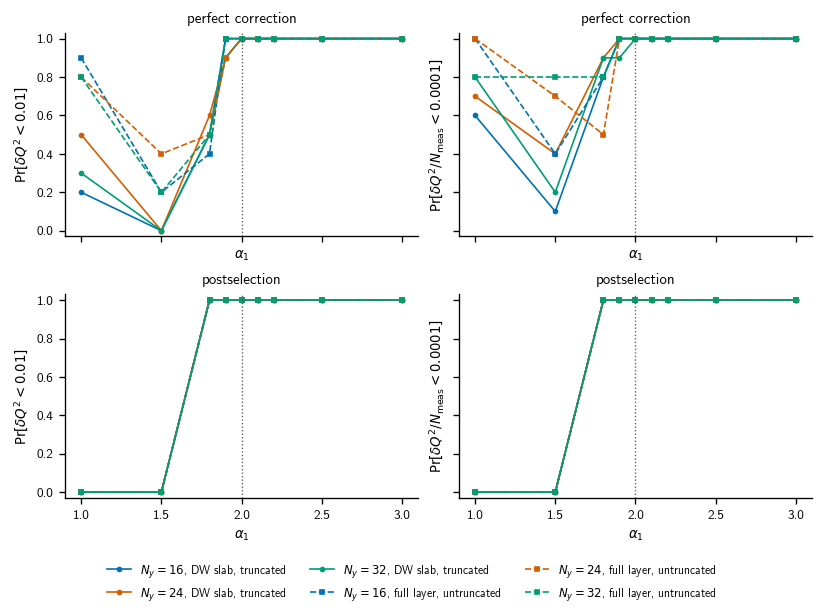

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.0), constrained_layout=True, sharex=True, sharey=True)
COLUMNS = (
    ('sharpening_fraction', rf'$\Pr[\delta Q^2 < {SHARPENING_THRESHOLD:g}]$'),
    ('density_sharpening_fraction', rf'$\Pr[\delta Q^2/N_{{\mathrm{{meas}}}} < {DENSITY_SHARPENING_THRESHOLD:g}]$'),
)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, (field, ylabel) in enumerate(COLUMNS):
        ax = axes[row, col]
        for truncation in ('dwtrunc1', 'dwtrunc0'):
            for ny in NY_VALUES:
                data = steady_state_df.query('protocol == @protocol and truncation == @truncation and Ny == @ny').sort_values('alpha_topological_region')
                ax.plot(data['alpha_topological_region'], data[field], TRUNC_STYLES[truncation], marker=TRUNC_MARKERS[truncation], ms=2.4, lw=1.0, color=NY_COLORS[ny], label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}')
        ax.axvline(2.0, color='0.35', lw=0.8, ls=':')
        ax.set_title(PROTOCOL_LABELS[protocol])
        ax.set_xlabel(r'$\alpha_1$')
        ax.set_ylabel(ylabel)
        ax.set_ylim(-0.03, 1.03)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'final_sharpening_fraction_raw_and_density_dwtrunc_comparison')
plt.show()

## Cycle Dynamics: Entropy

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/global_entropy_vs_cycle_alpha_1_2_3_dwtrunc_comparison.png


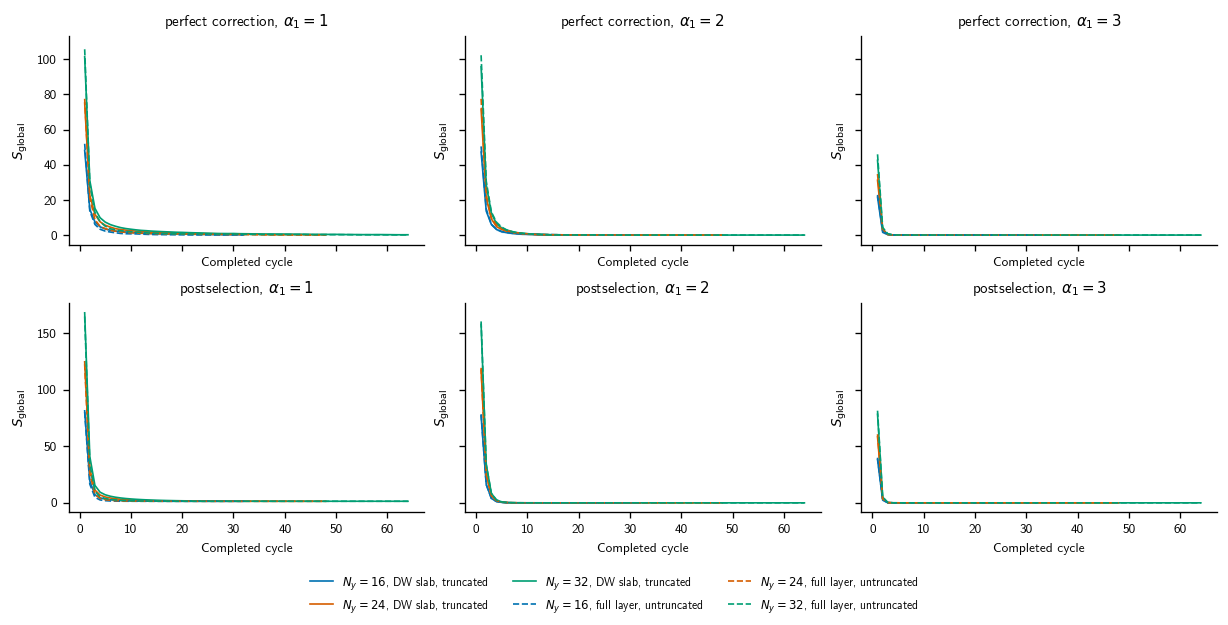

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10.125, 5.1), constrained_layout=True, sharex=True, sharey='row')
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, alpha_value in enumerate((1.0, 2.0, 3.0)):
        ax = axes[row, col]
        for truncation in ('dwtrunc1', 'dwtrunc0'):
            for ny in NY_VALUES:
                data = dynamics_df.query('protocol == @protocol and truncation == @truncation and Ny == @ny and alpha_topological_region == @alpha_value').sort_values('cycle')
                x = data['cycle'].to_numpy()
                y = data['total_entropy_mean'].to_numpy()
                err = data['total_entropy_std'].to_numpy()
                ax.plot(x, y, TRUNC_STYLES[truncation], color=NY_COLORS[ny], lw=1.0, label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}')
                if protocol == 'perfect_correction':
                    ax.fill_between(x, y - err, y + err, color=NY_COLORS[ny], alpha=0.10, linewidth=0)
        ax.set_title(rf'{PROTOCOL_LABELS[protocol]}, $\alpha_1={alpha_value:g}$')
        ax.set_xlabel('Completed cycle')
        ax.set_ylabel(r'$S_{\mathrm{global}}$')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'global_entropy_vs_cycle_alpha_1_2_3_dwtrunc_comparison')
plt.show()

## Cycle Dynamics: Charge Variance

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/total_charge_variance_vs_cycle_alpha_1_2_3_dwtrunc_comparison.png


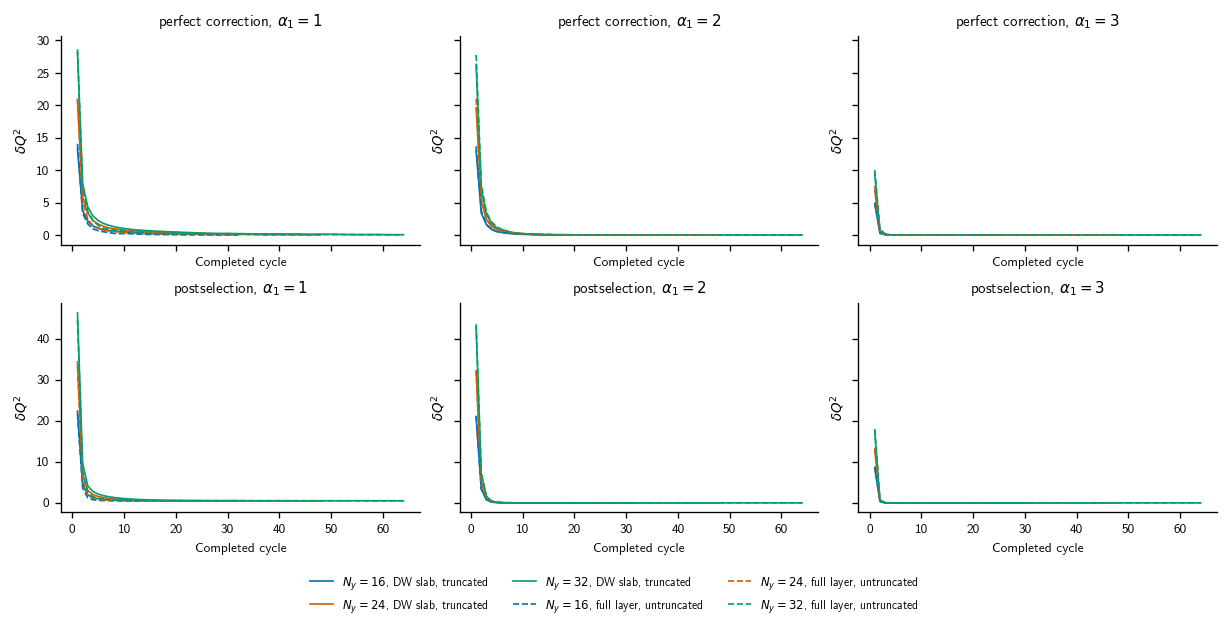

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10.125, 5.1), constrained_layout=True, sharex=True, sharey='row')
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, alpha_value in enumerate((1.0, 2.0, 3.0)):
        ax = axes[row, col]
        for truncation in ('dwtrunc1', 'dwtrunc0'):
            for ny in NY_VALUES:
                data = dynamics_df.query('protocol == @protocol and truncation == @truncation and Ny == @ny and alpha_topological_region == @alpha_value').sort_values('cycle')
                x = data['cycle'].to_numpy()
                y = data['total_charge_variance_mean'].to_numpy()
                err = data['total_charge_variance_std'].to_numpy()
                ax.plot(x, y, TRUNC_STYLES[truncation], color=NY_COLORS[ny], lw=1.0, label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}')
                if protocol == 'perfect_correction':
                    ax.fill_between(x, y - err, y + err, color=NY_COLORS[ny], alpha=0.10, linewidth=0)
        ax.set_title(rf'{PROTOCOL_LABELS[protocol]}, $\alpha_1={alpha_value:g}$')
        ax.set_xlabel('Completed cycle')
        ax.set_ylabel(r'$\delta Q^2$')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'total_charge_variance_vs_cycle_alpha_1_2_3_dwtrunc_comparison')
plt.show()

## Difference Heatmaps

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_density_difference_heatmaps_dwtrunc0_minus_dwtrunc1.png


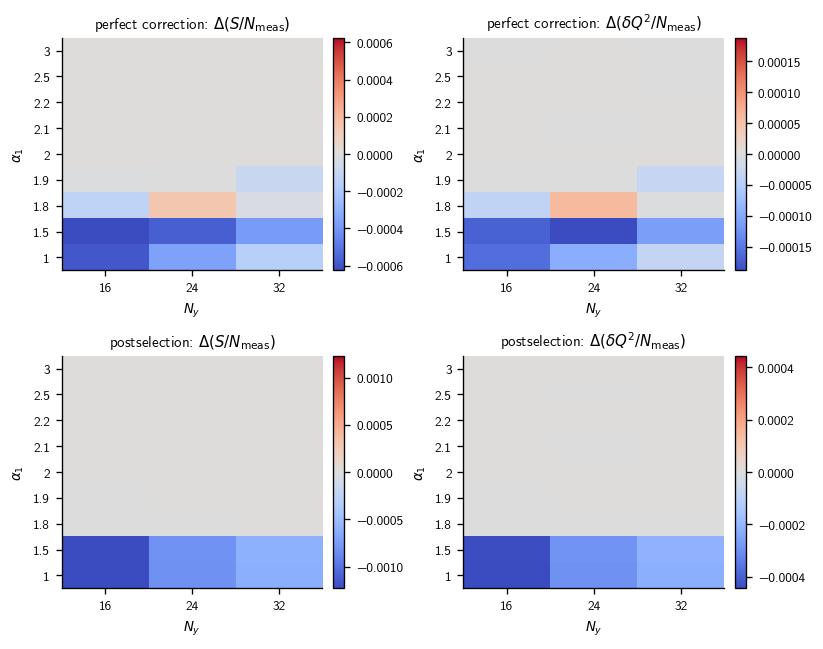

In [11]:
def pivot_for_heatmap(frame, field, protocol, truncation):
    return (
        frame.query('protocol == @protocol and truncation == @truncation')
        .pivot(index='alpha_topological_region', columns='Ny', values=field)
        .sort_index(ascending=False)
    )

fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.3), constrained_layout=True)
FIELDS = (
    ('entropy_per_mode_mean', r'$\Delta(S/N_{\mathrm{meas}})$'),
    ('charge_variance_per_mode_mean', r'$\Delta(\delta Q^2/N_{\mathrm{meas}})$'),
)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, (field, title) in enumerate(FIELDS):
        ax = axes[row, col]
        diff = pivot_for_heatmap(steady_state_df, field, protocol, 'dwtrunc0') - pivot_for_heatmap(steady_state_df, field, protocol, 'dwtrunc1')
        vmax = float(np.nanmax(np.abs(diff.to_numpy())))
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax) if vmax > 0 else None
        image = ax.imshow(diff.to_numpy(), aspect='auto', cmap='coolwarm', norm=norm)
        ax.set_title(f'{PROTOCOL_LABELS[protocol]}: {title}')
        ax.set_xlabel(r'$N_y$')
        ax.set_ylabel(r'$\alpha_1$')
        ax.set_xticks(range(len(diff.columns)), [str(int(value)) for value in diff.columns])
        ax.set_yticks(range(len(diff.index)), [f'{value:g}' for value in diff.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
save_figure(fig, 'final_density_difference_heatmaps_dwtrunc0_minus_dwtrunc1')
plt.show()

## Raw Log-Ratio Heatmaps

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_raw_log_ratio_heatmaps_dwtrunc0_over_dwtrunc1.png


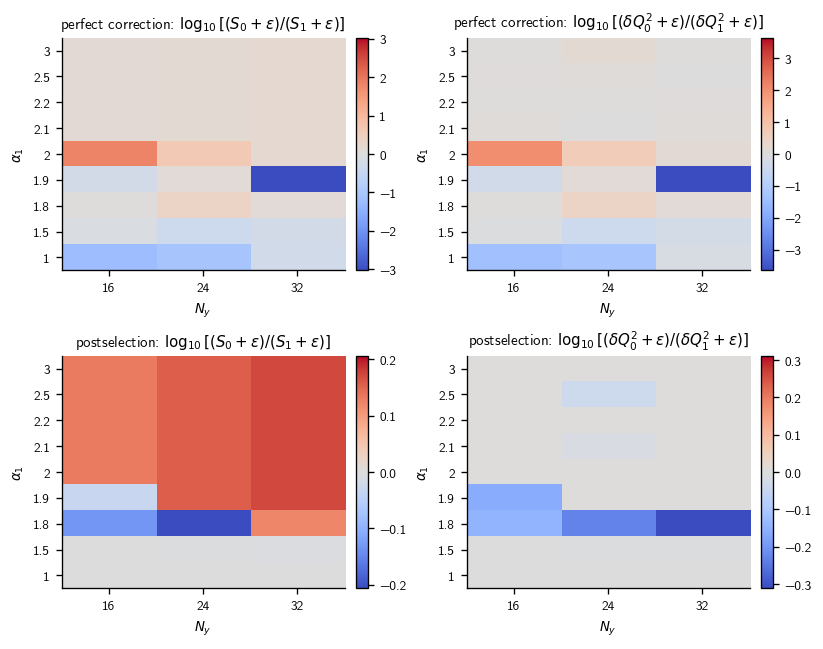

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.3), constrained_layout=True)
FIELDS = (
    ('total_entropy_mean', r'$\log_{10}[(S_0+\epsilon)/(S_1+\epsilon)]$', 1e-8),
    ('total_charge_variance_mean', r'$\log_{10}[(\delta Q^2_0+\epsilon)/(\delta Q^2_1+\epsilon)]$', 1e-12),
)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for col, (field, title, floor) in enumerate(FIELDS):
        ax = axes[row, col]
        ratio = np.log10(
            (pivot_for_heatmap(steady_state_df, field, protocol, 'dwtrunc0') + floor)
            / (pivot_for_heatmap(steady_state_df, field, protocol, 'dwtrunc1') + floor)
        )
        vmax = float(np.nanmax(np.abs(ratio.to_numpy())))
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax) if vmax > 0 else None
        image = ax.imshow(ratio.to_numpy(), aspect='auto', cmap='coolwarm', norm=norm)
        ax.set_title(f'{PROTOCOL_LABELS[protocol]}: {title}')
        ax.set_xlabel(r'$N_y$')
        ax.set_ylabel(r'$\alpha_1$')
        ax.set_xticks(range(len(ratio.columns)), [str(int(value)) for value in ratio.columns])
        ax.set_yticks(range(len(ratio.index)), [f'{value:g}' for value in ratio.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
save_figure(fig, 'final_raw_log_ratio_heatmaps_dwtrunc0_over_dwtrunc1')
plt.show()

## Raw Heatmaps By Campaign

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/final_raw_heatmaps_by_truncation_and_protocol.png


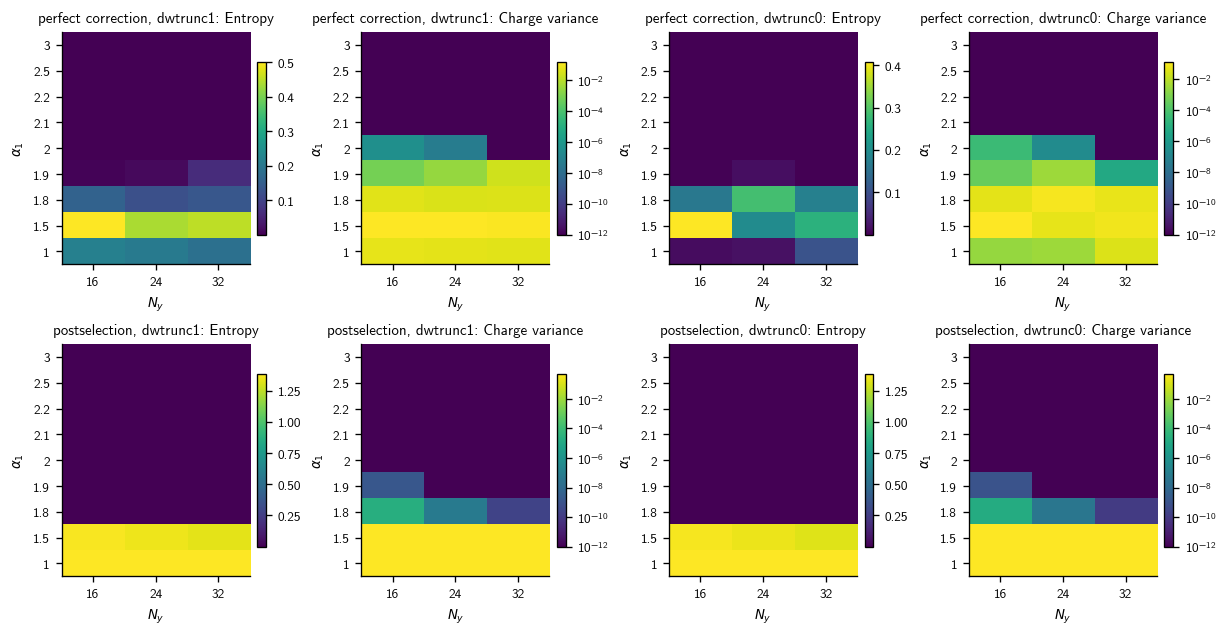

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(10.125, 5.2), constrained_layout=True)
for row, protocol in enumerate(('perfect_correction', 'postselection')):
    for truncation_index, truncation in enumerate(('dwtrunc1', 'dwtrunc0')):
        for obs_index, (field, title, ylabel, floor) in enumerate(OBSERVABLES):
            col = 2 * truncation_index + obs_index
            ax = axes[row, col]
            grid = pivot_for_heatmap(steady_state_df, f'{field}_mean', protocol, truncation)
            values = grid.to_numpy()
            if field == 'total_charge_variance':
                values = np.maximum(values, floor)
                norm = LogNorm(vmin=floor, vmax=max(floor * 10, float(np.nanmax(values))))
            else:
                norm = None
            image = ax.imshow(values, aspect='auto', cmap='viridis', norm=norm)
            ax.set_title(f'{PROTOCOL_LABELS[protocol]}, {truncation}: {title}')
            ax.set_xlabel(r'$N_y$')
            ax.set_ylabel(r'$\alpha_1$')
            ax.set_xticks(range(len(grid.columns)), [str(int(value)) for value in grid.columns])
            ax.set_yticks(range(len(grid.index)), [f'{value:g}' for value in grid.index])
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
save_figure(fig, 'final_raw_heatmaps_by_truncation_and_protocol')
plt.show()

## Perfect-Correction Final-Cycle Sample Spread

/home/abhuiyan/class_A_fermionic_adaptive_circuit/colab_charge_fluctuations/analysis_outputs/purification_charge_sharpening_alpha_sweep_cpu/dwtrunc0_vs_dwtrunc1_N16_alpha_sweep/figures/perfect_correction_final_cycle_spread_dwtrunc_comparison.png


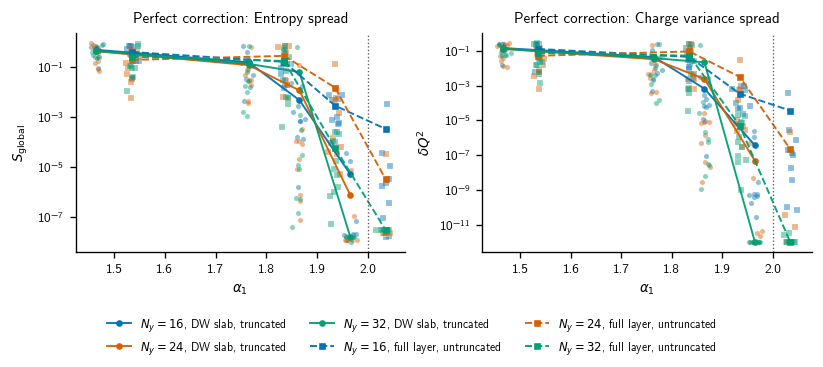

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 2.95), constrained_layout=True)
rng = np.random.default_rng(39421)
offsets = {'dwtrunc1': -0.035, 'dwtrunc0': 0.035}
focus = final_trajectory_df.query("protocol == 'perfect_correction' and alpha_topological_region in [1.5, 1.8, 1.9, 2.0]").copy()
for ax, (field, title, ylabel, floor) in zip(axes, OBSERVABLES):
    for truncation in ('dwtrunc1', 'dwtrunc0'):
        for ny in NY_VALUES:
            data = focus.query('truncation == @truncation and Ny == @ny')
            x = data['alpha_topological_region'].to_numpy() + offsets[truncation] + rng.normal(0.0, 0.006, len(data))
            y = np.maximum(data[field].to_numpy(), floor)
            ax.scatter(
                x, y, s=10, alpha=0.45, color=NY_COLORS[ny], marker=TRUNC_MARKERS[truncation],
                linewidths=0.2, edgecolors='white', label='_nolegend_'
            )
            mean_data = (
                data.groupby('alpha_topological_region', as_index=False)[field]
                .mean()
                .sort_values('alpha_topological_region')
            )
            ax.plot(
                mean_data['alpha_topological_region'].to_numpy() + offsets[truncation],
                np.maximum(mean_data[field].to_numpy(), floor),
                TRUNC_STYLES[truncation], color=NY_COLORS[ny], marker=TRUNC_MARKERS[truncation],
                ms=3.0, lw=1.15, alpha=0.95, label=rf'$N_y={ny}$, {TRUNC_LABELS[truncation]}'
            )
    ax.axvline(2.0, color='0.35', lw=0.8, ls=':')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\alpha_1$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Perfect correction: {title} spread')
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='outside lower center', ncol=3, frameon=False)
save_figure(fig, 'perfect_correction_final_cycle_spread_dwtrunc_comparison')
plt.show()


## Numeric Summary Tables

In [15]:
summary_fields = ['total_entropy_mean', 'total_charge_variance_mean', 'entropy_per_mode_mean', 'charge_variance_per_mode_mean', 'sharpening_fraction', 'density_sharpening_fraction']
for protocol in ('perfect_correction', 'postselection'):
    print(f'\n[{protocol}]')
    table = steady_state_df.query('protocol == @protocol').pivot_table(index=['truncation', 'alpha_topological_region'], columns='Ny', values=summary_fields)
    display(table.round(6))


[perfect_correction]


charge_variance_per_mode_mean            \
Ny                                                             16        24   
truncation alpha_topological_region                                           
dwtrunc0   1.0                                           0.000005  0.000004   
           1.5                                           0.000258  0.000070   
           1.8                                           0.000090  0.000124   
           1.9                                           0.000001  0.000004   
           2.0                                           0.000000  0.000000   
           2.1                                           0.000000  0.000000   
           2.2                                           0.000000  0.000000   
           2.5                                           0.000000  0.000000   
           3.0                                           0.000000  0.000000   
dwtrunc1   1.0                                           0.000163  0.000101   
           1.5                                           0.000427  0.000258   
           1.8                                           0.000128  0.000064   
           1.9                                           0.000002  0.000005   
           2.0                                           0.000000  0.000000   
           2.1                                           0.000000  0.000000   
           2.2                                           0.000000  0.000000   
           2.5                                           0.000000  0.000000   
           3.0                                           0.000000  0.000000   

                                              density_sharpening_fraction  \
Ny                                         32                          16   
truncation alpha_topological_region                                         
dwtrunc0   1.0                       0.000032                         1.0   
           1.5                       0.000076                         0.4   
           1.8                       0.000053                         0.8   
           1.9                       0.000000                         1.0   
           2.0                       0.000000                         1.0   
           2.1                       0.000000                         1.0   
           2.2                       0.000000                         1.0   
           2.5                       0.000000                         1.0   
           3.0                       0.000000                         1.0   
dwtrunc1   1.0                       0.000066                         0.6   
           1.5                       0.000189                         0.1   
           1.8                       0.000056                         0.8   
           1.9                       0.000032                         1.0   
           2.0                       0.000000                         1.0   
           2.1                       0.000000                         1.0   
           2.2                       0.000000                         1.0   
           2.5                       0.000000                         1.0   
           3.0                       0.000000                         1.0   

                                              entropy_per_mode_mean            \
Ny                                    24   32                    16        24   
truncation alpha_topological_region                                             
dwtrunc0   1.0                       1.0  0.8              0.000026  0.000024   
           1.5                       0.7  0.8              0.000798  0.000256   
           1.8                       0.5  0.8              0.000321  0.000373   
           1.9                       1.0  1.0              0.000006  0.000020   
           2.0                       1.0  1.0              0.000001  0.000000   
           2.1                       1.0  1.0              0.000000  0.000000   
           2.2               


[postselection]


charge_variance_per_mode_mean            \
Ny                                                             16        24   
truncation alpha_topological_region                                           
dwtrunc0   1.0                                           0.000977  0.000651   
           1.5                                           0.000960  0.000626   
           1.8                                           0.000000  0.000000   
           1.9                                           0.000000  0.000000   
           2.0                                           0.000000  0.000000   
           2.1                                           0.000000  0.000000   
           2.2                                           0.000000  0.000000   
           2.5                                           0.000000  0.000000   
           3.0                                           0.000000  0.000000   
dwtrunc1   1.0                                           0.001420  0.000947   
           1.5                                           0.001400  0.000916   
           1.8                                           0.000000  0.000000   
           1.9                                           0.000000  0.000000   
           2.0                                           0.000000  0.000000   
           2.1                                           0.000000  0.000000   
           2.2                                           0.000000  0.000000   
           2.5                                           0.000000  0.000000   
           3.0                                           0.000000  0.000000   

                                              density_sharpening_fraction  \
Ny                                         32                          16   
truncation alpha_topological_region                                         
dwtrunc0   1.0                       0.000488                         0.0   
           1.5                       0.000455                         0.0   
           1.8                       0.000000                         1.0   
           1.9                       0.000000                         1.0   
           2.0                       0.000000                         1.0   
           2.1                       0.000000                         1.0   
           2.2                       0.000000                         1.0   
           2.5                       0.000000                         1.0   
           3.0                       0.000000                         1.0   
dwtrunc1   1.0                       0.000710                         0.0   
           1.5                       0.000669                         0.0   
           1.8                       0.000000                         1.0   
           1.9                       0.000000                         1.0   
           2.0                       0.000000                         1.0   
           2.1                       0.000000                         1.0   
           2.2                       0.000000                         1.0   
           2.5                       0.000000                         1.0   
           3.0                       0.000000                         1.0   

                                              entropy_per_mode_mean            \
Ny                                    24   32                    16        24   
truncation alpha_topological_region                                             
dwtrunc0   1.0                       0.0  0.0              0.002708  0.001805   
           1.5                       0.0  0.0              0.002674  0.001755   
           1.8                       1.0  1.0              0.000000  0.000000   
           1.9                       1.0  1.0              0.000000  0.000000   
           2.0                       1.0  1.0              0.000000  0.000000   
           2.1                       1.0  1.0              0.000000  0.000000   
           2.2               